In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import seaborn as sns

In [29]:
aggStats = pd.read_parquet('data/processed/aggregate_stats.parquet')
events = pd.read_parquet('data/processed/events.parquet')
reports = pd.read_parquet('data/processed/storm_reports.parquet')

In [30]:
aggStats

,wfo,year,phenomena,events_total,events_verified,verification_rate,far,pod,csi,area_verify_pct,shared_border_pct,size_poly_vs_county_pct,avg_size_sqkm,avg_leadtime_min,max_leadtime_min,min_leadtime_min,reports_total,unwarned_reports,tdq_stormreports
0,ALY,2008,"TO,SV",247,109,0.441296,0.558704,0.758741,0.386993,NaN,NaN,NaN,1588.642814,24.576037,67,0,286,67,2
1,ALY,2009,"TO,SV",150,75,0.500000,0.500000,0.693277,0.409429,NaN,NaN,NaN,1397.116379,24.557576,64,1,238,73,0
2,ALY,2010,"TO,SV",105,70,0.666667,0.333333,0.706960,0.522327,NaN,NaN,NaN,2224.952325,24.000000,62,0,273,80,0
3,ALY,2011,"TO,SV",200,121,0.605000,0.395000,0.712871,0.486459,NaN,NaN,NaN,2364.658657,28.697222,75,0,505,141,4
4,ALY,2012,"TO,SV",128,80,0.625000,0.375000,0.830435,0.554266,NaN,NaN,NaN,1997.855191,25.471204,93,0,230,38,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,CAE,2017,"TO,SV",234,147,0.628205,0.371795,0.762963,0.525620,NaN,NaN,NaN,1516.354501,21.935275,63,1,405,83,13
100,CAE,2018,"TO,SV",184,134,0.728261,0.271739,0.760417,0.592346,NaN,NaN,NaN,1648.801860,17.914384,59,0,384,92,0
101,CAE,2019,"TO,SV",175,120,0.685714,0.314286,0.831984,0.602308,NaN,NaN,NaN,1819.335433,21.698297,58,0,494,75,8
102,ICT,2023,"TO,SV",270,131,0.485185,0.514815,0.859335,0.449487,NaN,NaN,NaN,1992.455257,25.005952,85,0,391,52,3


In [10]:
events

,event_id,wfo,phenomena,significance,eventid,year,issue,expire,verify,parea,...,status,fcster,ugc_codes,ugc_names,stormreports,size_reduction_pct,perimeter_ratio,geometry,month,season
0,2008ALY1SVW1,ALY,SV,W,1,2008,2008-01-09 12:11:00+00:00,2008-01-09 13:15:00+00:00,False,5642.591265,...,EXP,NAS,"[NYC043, NYC041]","[Herkimer NY, Hamilton NY]",,33.169124,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,1,DJF
1,2008ALY2SVW1,ALY,SV,W,2,2008,2008-01-09 15:45:00+00:00,2008-01-09 16:28:00+00:00,False,976.489548,...,CAN,TAW/JPV,"[VTC003, NYC115]","[Bennington VT, Washington NY]",,75.206256,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,1,DJF
2,2008ALY3SVW1,ALY,SV,W,3,2008,2008-03-09 01:01:00+00:00,2008-03-09 01:45:00+00:00,True,4218.411865,...,EXP,FRUGIS/KL,"[MAC003, CTC005, NYC083, NYC021]","[Berkshire MA, Litchfield CT, Rensselaer NY, C...","6,7,8,9",49.092260,0.0,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",3,MAM
3,2008ALY4SVW1,ALY,SV,W,4,2008,2008-04-01 23:10:00+00:00,2008-04-01 23:58:00+00:00,False,1358.543885,...,CAN,GJM,[NYC095],[Schoharie NY],,16.115571,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,4,MAM
4,2008ALY5SVW1,ALY,SV,W,5,2008,2008-04-02 00:59:00+00:00,2008-04-02 02:00:00+00:00,False,1190.863842,...,NEW,GJM,"[NYC021, MAC003, CTC005]","[Columbia NY, Berkshire MA, Litchfield CT]",,81.862673,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,4,MAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14977,2023OUN890SVW1,OUN,SV,W,890,2023,2023-11-20 06:08:00+00:00,2023-11-20 06:33:00+00:00,False,672.648141,...,CAN,..speg.,"[OKC027, OKC125, OKC087]","[Cleveland OK, Pottawatomie OK, McClain OK]",,86.555902,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,11,SON
14978,2023OUN891SVW1,OUN,SV,W,891,2023,2023-11-20 08:30:00+00:00,2023-11-20 09:15:00+00:00,False,1347.743101,...,NEW,WR,"[OKC069, OKC095, OKC019]","[Johnston OK, Marshall OK, Carter OK]",,72.893379,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,11,SON
14979,2023OUN892SVW1,OUN,SV,W,892,2023,2023-11-20 09:12:00+00:00,2023-11-20 10:00:00+00:00,False,1853.830241,...,NEW,WR,"[OKC005, OKC013, OKC069]","[Atoka OK, Bryan OK, Johnston OK]",,72.387661,0.0,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",11,SON
14980,2023OUN893SVW1,OUN,SV,W,893,2023,2023-11-20 20:48:00+00:00,2023-11-20 21:30:00+00:00,False,993.149365,...,CON,11,"[OKC029, OKC005]","[Coal OK, Atoka OK]",,74.631781,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,11,SON


In [11]:
reports

,report_id,wfo,lsrtype,typetext,magnitude,city,county,state,lat0,lon0,valid,warned,leadtime,remark,source,tdq
0,0,ALY,SV,TSTM WND DMG,NaN,SALISBURY,LITCHFIELD,CT,41.98,-73.42,2008-03-09 00:00:00+00:00,False,NaN,TREE REPORTED DOWN.,PUBLIC,False
1,1,ALY,SV,TSTM WND DMG,NaN,CHESHIRE,BERKSHIRE,MA,42.56,-73.15,2008-03-09 00:07:00+00:00,False,NaN,TREE AND WIRES DOWN.,EMERGENCY MNGR,False
2,2,ALY,SV,TSTM WND DMG,NaN,STOCKBRIDGE,BERKSHIRE,MA,42.29,-73.32,2008-03-09 00:10:00+00:00,False,NaN,LARGE TREE LIMB AND WIRES DOWN,EMERGENCY MNGR,False
3,3,ALY,SV,TSTM WND DMG,NaN,SHEFFIELD,BERKSHIRE,MA,42.11,-73.35,2008-03-09 00:12:00+00:00,False,NaN,TREE REPORTED DOWN.,TRAINED SPOTTER,False
4,4,ALY,SV,TSTM WND DMG,NaN,FALLS VILLAGE,LITCHFIELD,CT,41.95,-73.36,2008-03-09 00:30:00+00:00,False,NaN,SEVERAL TREES DOWN ON RT 7,EMERGENCY MNGR,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34558,954,OUN,FF,FLASH FLOOD,NaN,Ponca City,Kay,OK,36.70,-97.08,2023-10-24 20:20:00+00:00,False,NaN,Widespread city street flooding. Portion of Bu...,Emergency Mngr,False
34559,955,OUN,FF,FLASH FLOOD,NaN,2 S Kildare,Kay,OK,36.78,-97.05,2023-10-24 20:40:00+00:00,False,NaN,Roadway flooded near the intersection of Tower...,Law Enforcement,False
34560,956,OUN,FF,FLASH FLOOD,NaN,7 NNW Cache,Comanche,OK,34.72,-98.67,2023-10-24 23:30:00+00:00,False,NaN,Social media image showing water overtopping t...,Public,False
34561,957,OUN,TO,TORNADO,NaN,5 SSW Wynnewood,Garvin,OK,34.58,-97.20,2023-10-25 21:58:00+00:00,False,NaN,Motorists along Interstate 35 captured video a...,Public,False


In [35]:
reportsSouth = reports[reports['state'].isin(['MD', 'DE', 'DC', 'WV', 'VA', 'NC', 'SC', 'KY', 'TN', 'GA', 'FL', 'AL', 'MS', 'AR', 'LA', 'OK', 'TX'])]
reportsSouth = reportsSouth.reset_index()
reportsSouth

,index,report_id,wfo,lsrtype,typetext,magnitude,city,county,state,lat0,lon0,valid,warned,leadtime,remark,source,tdq
0,28882,0,CAE,SV,TSTM WND DMG,NaN,5 N MIDVILLE,BURKE,GA,32.89,-82.24,2008-02-06 20:22:00+00:00,True,19.0,TWO TREES DOWN ALONG CROOKED RD BETWEEN HIGHWA...,DEPT OF HIGHWAYS,False
1,28883,1,CAE,TO,TORNADO,NaN,2 ESE PROSPERITY,NEWBERRY,SC,34.20,-81.51,2008-03-04 21:23:00+00:00,True,7.0,A NWS STORM SURVEY CONFIRMED THAT A TORNADO......,NWS STORM SURVEY,False
2,28884,2,CAE,TO,TORNADO,NaN,4 ENE GREAT FALLS,LANCASTER,SC,34.59,-80.84,2008-03-04 21:42:00+00:00,True,4.0,A TORNADO...OF MAGNITUDE EF-0...BRIEFLY TOUCHE...,NWS STORM SURVEY,False
3,28885,3,CAE,SV,TSTM WND DMG,NaN,NEW ELLENTON,AIKEN,SC,33.42,-81.69,2008-03-05 00:19:00+00:00,False,NaN,TREES DOWN IN NEW ELLENTON. OTHER TREES WERE D...,NWS EMPLOYEE,True
4,28886,4,CAE,SV,TSTM WND DMG,NaN,AUGUSTA,RICHMOND,GA,33.46,-82.00,2008-03-05 01:05:00+00:00,False,NaN,MINOR ROOF DAMAGE TO A RESTAURANT NEAR US 1 AN...,NWS EMPLOYEE,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5281,34558,954,OUN,FF,FLASH FLOOD,NaN,Ponca City,Kay,OK,36.70,-97.08,2023-10-24 20:20:00+00:00,False,NaN,Widespread city street flooding. Portion of Bu...,Emergency Mngr,False
5282,34559,955,OUN,FF,FLASH FLOOD,NaN,2 S Kildare,Kay,OK,36.78,-97.05,2023-10-24 20:40:00+00:00,False,NaN,Roadway flooded near the intersection of Tower...,Law Enforcement,False
5283,34560,956,OUN,FF,FLASH FLOOD,NaN,7 NNW Cache,Comanche,OK,34.72,-98.67,2023-10-24 23:30:00+00:00,False,NaN,Social media image showing water overtopping t...,Public,False
5284,34561,957,OUN,TO,TORNADO,NaN,5 SSW Wynnewood,Garvin,OK,34.58,-97.20,2023-10-25 21:58:00+00:00,False,NaN,Motorists along Interstate 35 captured video a...,Public,False


In [52]:
list(reportsSouth['state'].unique())
# only 5 states out of the 17 "Southern" states included in this data

['GA', 'SC', 'NC', 'OK', 'TX']

In [47]:
wfoSouth = list(reportsSouth['wfo'].unique())
wfoSouth
# only two offices lol

['CAE', 'OUN']

In [32]:
aggStatsSouth = aggStats[aggStats['wfo'].isin(wfoSouth)]
aggStatsSouth = aggStatsSouth.reset_index()
aggStatsSouth

,index,wfo,year,phenomena,events_total,events_verified,verification_rate,far,pod,csi,area_verify_pct,shared_border_pct,size_poly_vs_county_pct,avg_size_sqkm,avg_leadtime_min,max_leadtime_min,min_leadtime_min,reports_total,unwarned_reports,tdq_stormreports
0,90,CAE,2008,"TO,SV",306,134,0.437908,0.562092,0.689542,0.365789,NaN,NaN,NaN,1266.018389,20.616114,54,0,306,68,27
1,91,CAE,2009,"TO,SV",212,108,0.509434,0.490566,0.781395,0.445886,NaN,NaN,NaN,1700.501459,25.273810,67,2,215,41,6
2,92,CAE,2010,"TO,SV",254,160,0.629921,0.370079,0.836667,0.560941,NaN,NaN,NaN,1531.548723,18.864542,65,0,300,46,3
3,93,CAE,2011,"TO,SV",311,207,0.665595,0.334405,0.847788,0.594546,NaN,NaN,NaN,2354.301468,27.331942,79,0,565,82,4
4,94,CAE,2012,"TO,SV",255,186,0.729412,0.270588,0.784091,0.607412,NaN,NaN,NaN,1582.887204,21.440580,79,0,440,92,3
5,95,CAE,2013,"TO,SV",103,82,0.796117,0.203883,0.736585,0.619689,NaN,NaN,NaN,2293.449055,23.529801,63,0,205,54,0
6,96,CAE,2014,"TO,SV",126,100,0.793651,0.206349,0.801802,0.663486,NaN,NaN,NaN,1443.694565,22.882022,59,0,222,44,0
7,97,CAE,2015,"TO,SV",188,143,0.760638,0.239362,0.669811,0.553207,NaN,NaN,NaN,1897.702100,23.211268,62,0,424,137,3
8,98,CAE,2016,"TO,SV",198,164,0.828283,0.171717,0.762803,0.658644,NaN,NaN,NaN,1747.639948,20.540636,70,0,371,88,0
9,99,CAE,2017,"TO,SV",234,147,0.628205,0.371795,0.762963,0.525620,NaN,NaN,NaN,1516.354501,21.935275,63,1,405,83,13


In [34]:
eventsSouth = events[events['wfo'].isin(wfoSouth)]
eventsSouth = eventsSouth.reset_index()
eventsSouth

,index,event_id,wfo,phenomena,significance,eventid,year,issue,expire,verify,...,status,fcster,ugc_codes,ugc_names,stormreports,size_reduction_pct,perimeter_ratio,geometry,month,season
0,11170,2008CAE1SVW1,CAE,SV,W,1,2008,2008-02-06 20:03:00+00:00,2008-02-06 20:45:00+00:00,True,...,EXP,HC,[GAC033],[Burke GA],0,9.451575,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,2,DJF
1,11171,2008CAE2TOW1,CAE,TO,W,2,2008,2008-03-04 21:16:00+00:00,2008-03-04 21:45:00+00:00,True,...,EXP,None,[SCC071],[Newberry SC],1,60.006447,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,3,MAM
2,11172,2008CAE3TOW1,CAE,TO,W,3,2008,2008-03-04 21:38:00+00:00,2008-03-04 22:15:00+00:00,True,...,EXP,None,[SCC057],[Lancaster SC],2,44.573031,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,3,MAM
3,11173,2008CAE2SVW1,CAE,SV,W,2,2008,2008-03-04 23:35:00+00:00,2008-03-04 23:59:00+00:00,False,...,CAN,None,"[SCC065, GAC181]","[McCormick SC, Lincoln GA]",,37.667034,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,3,MAM
4,11174,2008CAE4TOW1,CAE,TO,W,4,2008,2008-03-05 00:06:00+00:00,2008-03-05 00:45:00+00:00,False,...,CON,None,[SCC003],[Aiken SC],,45.897675,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,3,MAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3537,14977,2023OUN890SVW1,OUN,SV,W,890,2023,2023-11-20 06:08:00+00:00,2023-11-20 06:33:00+00:00,False,...,CAN,..speg.,"[OKC027, OKC125, OKC087]","[Cleveland OK, Pottawatomie OK, McClain OK]",,86.555902,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,11,SON
3538,14978,2023OUN891SVW1,OUN,SV,W,891,2023,2023-11-20 08:30:00+00:00,2023-11-20 09:15:00+00:00,False,...,NEW,WR,"[OKC069, OKC095, OKC019]","[Johnston OK, Marshall OK, Carter OK]",,72.893379,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,11,SON
3539,14979,2023OUN892SVW1,OUN,SV,W,892,2023,2023-11-20 09:12:00+00:00,2023-11-20 10:00:00+00:00,False,...,NEW,WR,"[OKC005, OKC013, OKC069]","[Atoka OK, Bryan OK, Johnston OK]",,72.387661,0.0,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",11,SON
3540,14980,2023OUN893SVW1,OUN,SV,W,893,2023,2023-11-20 20:48:00+00:00,2023-11-20 21:30:00+00:00,False,...,CON,11,"[OKC029, OKC005]","[Coal OK, Atoka OK]",,74.631781,0.0,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,11,SON


In [37]:
reportsSouth['typetext'].value_counts()

typetext
TSTM WND DMG     3347
HAIL              946
FLASH FLOOD       448
TSTM WND GST      373
TORNADO           170
TSTM WIND DMG       1
WATER SPOUT         1
Name: count, dtype: int64

In [ ]:
typeCounts = reportsSouth.groupby(['state', 'typetext'])['typetext'].count().unstack()
typeCounts
typeCountsSTD = typeCounts.div(typeCounts.sum(axis = 1), axis = 0)
typeCountsSTD

typetext,FLASH FLOOD,HAIL,TORNADO,TSTM WIND DMG,TSTM WND DMG,TSTM WND GST,WATER SPOUT
state,,,,,,,
GA,0.085366,0.144309,0.028455,NaN,0.705285,0.036585,NaN
NC,NaN,0.100000,0.100000,NaN,0.700000,0.100000,NaN
OK,0.041176,0.404706,0.041176,NaN,0.232941,0.280000,NaN
SC,0.096209,0.127320,0.030850,0.000261,0.725229,0.019869,0.000261
TX,0.027523,0.394495,0.018349,NaN,0.192661,0.366972,NaN


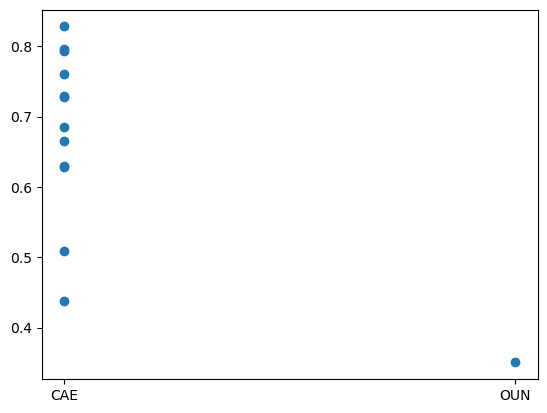

In [45]:
plt.scatter(aggStatsSouth['wfo'], aggStatsSouth['verification_rate'])
plt.show()
# not really a lot to work with here, very little data

<Axes: xlabel='typetext', ylabel='state'>

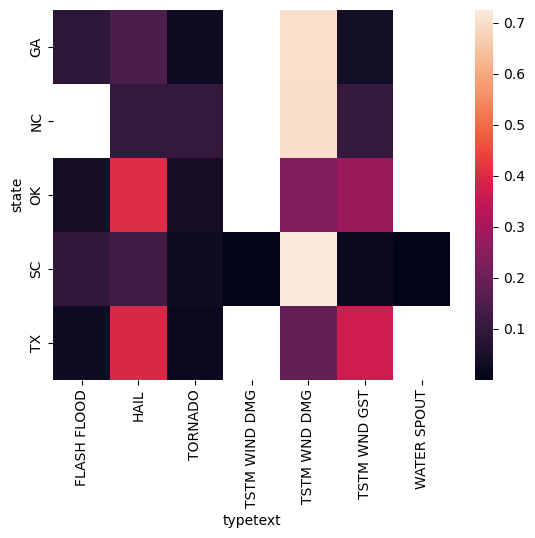

In [48]:
sns.heatmap(typeCountsSTD)